In [3]:
# We will download the Energy Efficiency Dataset from Kaggle
!pip install kagglehub

In [4]:
import kagglehub
import os
# Download latest version
path = kagglehub.dataset_download("elikplim/eergy-efficiency-dataset")

print("Path to dataset files:", path)

# List all files/folders in the downloaded directory
print(os.listdir(path))

Path to dataset files: C:\Users\gladys.fontanilla\.cache\kagglehub\datasets\elikplim\eergy-efficiency-dataset\versions\1
['ENB2012_data.csv']


In [5]:
# Join into the directory path
file_csv='ENB2012_data.csv'
energy_csv=os.path.join(path, file_csv)

In [6]:
# We will first conduct an exploratory data analysis to get an idea about the relationships between features and target variables
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [7]:
# Convert the data into pandas dataframe
df_energy=pd.read_csv(energy_csv)
print(df_energy.info())
df_energy.rename(columns={'X1':'Relative Compactness', 'X2':'Surface Area', 'X3':'Wall Area', 'X4':'Roof Area', 'X6':'Orientation', 'X5':'Overall Height', 'X7':'Glazing Area', 'X8':'Glazing Area Distribution', 'Y1': 'Heating Load', 'Y2':'Cooling Load'}, inplace=True)
df_energy.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X1      768 non-null    float64
 1   X2      768 non-null    float64
 2   X3      768 non-null    float64
 3   X4      768 non-null    float64
 4   X5      768 non-null    float64
 5   X6      768 non-null    int64  
 6   X7      768 non-null    float64
 7   X8      768 non-null    int64  
 8   Y1      768 non-null    float64
 9   Y2      768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB
None


,Relative Compactness,Surface Area,Wall Area,Roof Area,Overall Height,Orientation,Glazing Area,Glazing Area Distribution,Heating Load,Cooling Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [8]:
# X7 and X8 seems to be categorical, checking the uniqe values on each
print(df_energy['Orientation'].value_counts())
print(df_energy['Glazing Area Distribution'].value_counts())

Orientation
2    192
3    192
4    192
5    192
Name: count, dtype: int64
Glazing Area Distribution
1    144
2    144
4    144
3    144
5    144
0     48
Name: count, dtype: int64


Text(0.5, 1.0, 'Cooling Load Histogram')

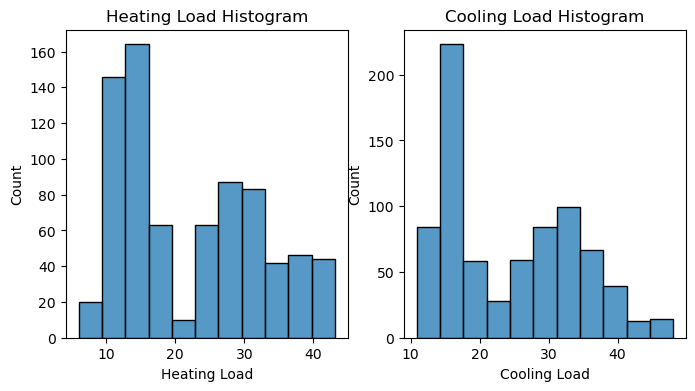

In [9]:
# Check first the distribution of the target variable
fig, axes=plt.subplots(nrows=1, ncols=2, figsize=(8,4))
sns.histplot(data=df_energy, x='Heating Load', kde=False, ax=axes[0])
axes[0].set_title("Heating Load Histogram")

sns.histplot(data=df_energy, x='Cooling Load', kde=False, ax=axes[1])
axes[1].set_title("Cooling Load Histogram")
# For starters, we will try to model the heating load, Y1

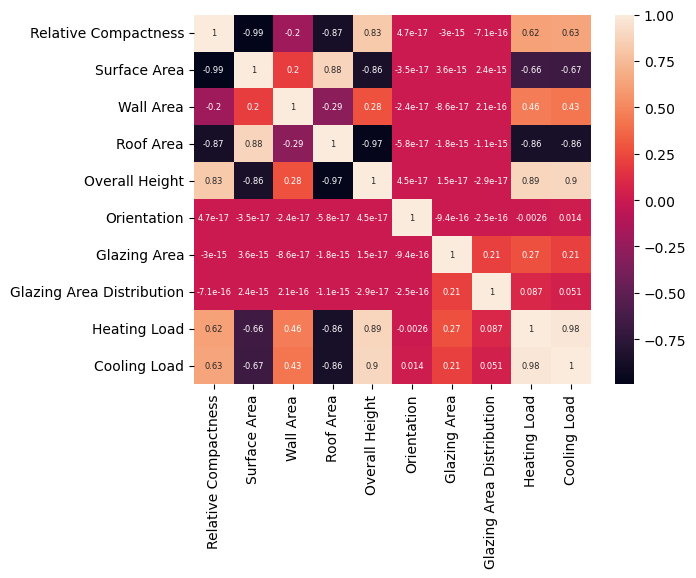

In [10]:
#Checking the correlation
sns.heatmap(df_energy.corr(), linecolor='white', annot=True, annot_kws={"size": 6})
plt.show()

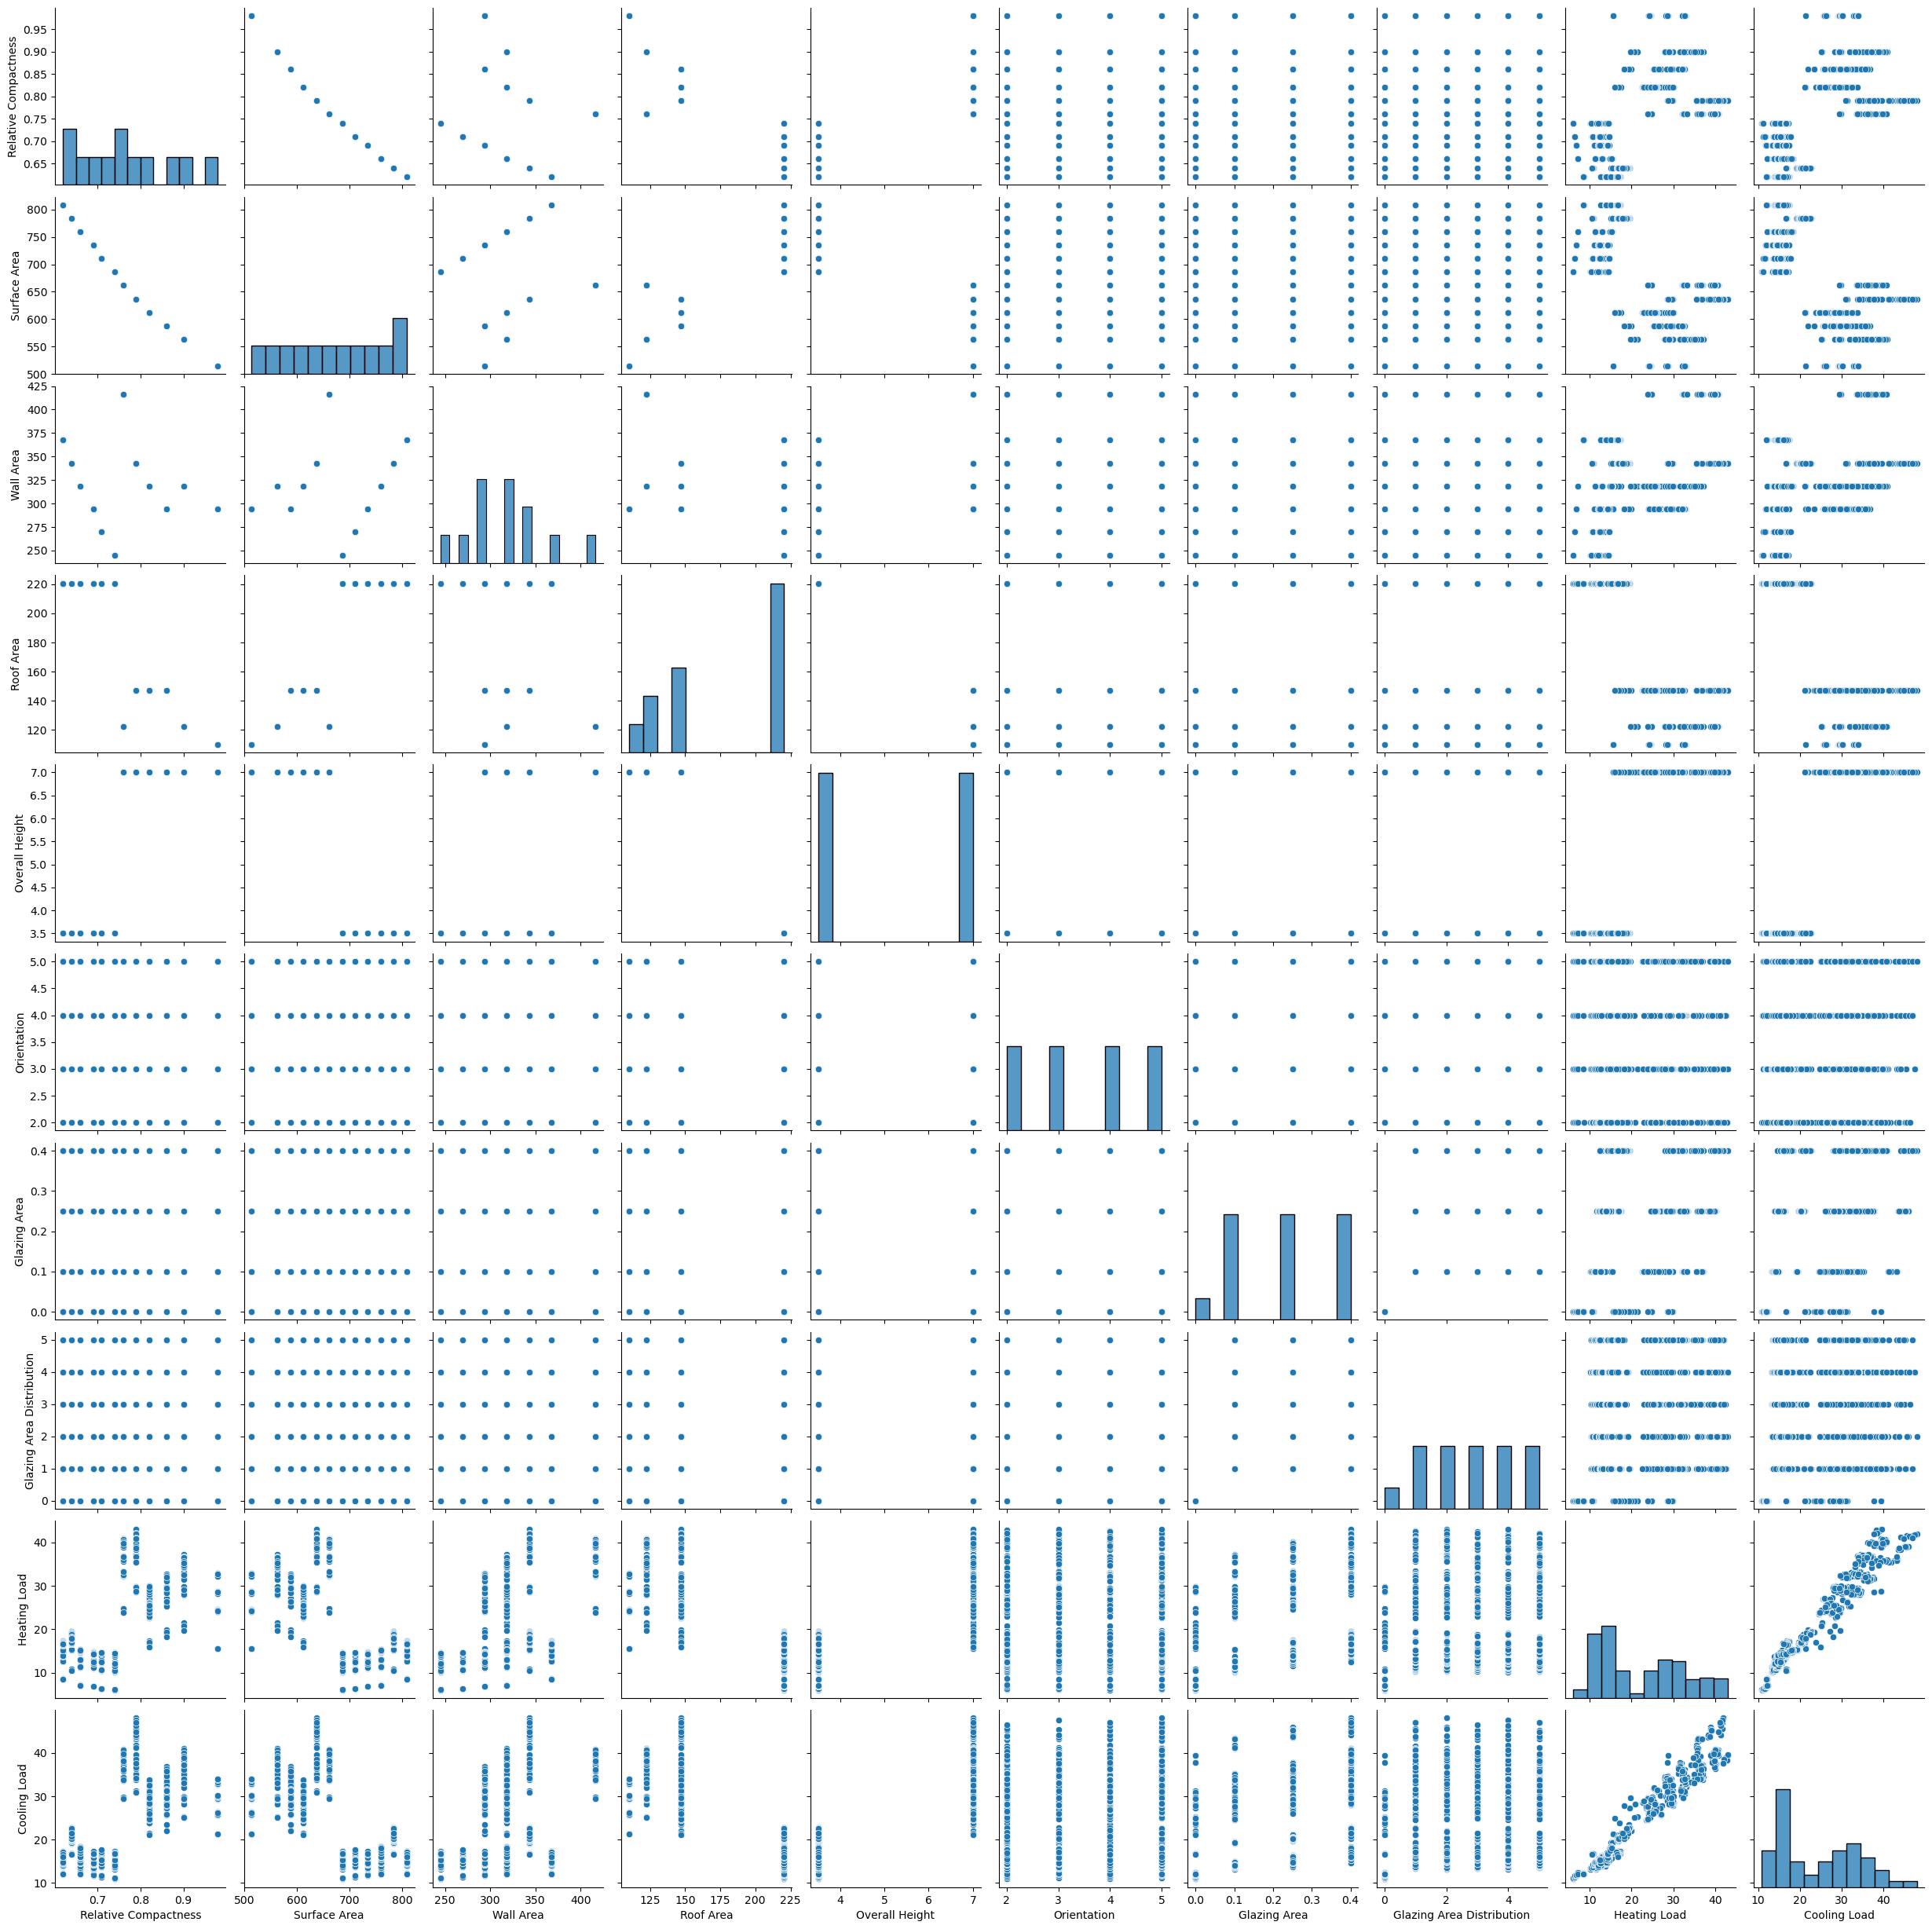

In [11]:
# Pairplot
sns.pairplot(df_energy)

In [12]:
!pip install scikit-learn

In [13]:
X = df_energy.drop(columns=['Heating Load', 'Cooling Load'])
y = df_energy['Heating Load']

In [ ]:
#Preprocessing and training
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


In [59]:
# We first identify the categorical and numerical features
numeric_features=["Relative Compactness", "Surface Area", "Wall Area",
    "Roof Area", "Overall Height", "Glazing Area"]
categorical_features=["Orientation", "Glazing Area Distribution"]

In [60]:
# Create a pipeline to transform the features
numerical_transformer=Pipeline(steps=[("scaler", StandardScaler())])
categorical_transformer=Pipeline(steps=[("onehot", OneHotEncoder(drop="first"))])
preprocessor=ColumnTransformer(transformers=[("num", numerical_transformer, numeric_features), ("cat", categorical_transformer, categorical_features)])

In [61]:
# Using the train-test split
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [62]:
# We use linear regression as a base model to check if the relationships are roughly linear before using complex models
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
lin_reg=Pipeline(steps=[("preprocessor", preprocessor), ("model", LinearRegression())])
lin_reg.fit(X_train, y_train)
y_pred=lin_reg.predict(X_test)

#Metrics
print("RMSE: \n", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R^2: \n", r2_score(y_test, y_pred))

RMSE: 
 2.998579144666149
R^2: 
 0.9079034180718755


In [19]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

In [20]:
# Now we do hyperparameter finetuning
ridge=Pipeline(steps=[("preprocessor", preprocessor), ("model", Ridge())])
param_grid={"model__alpha": [0.01, 0.1,1,100]}

grid_ridge=GridSearchCV(ridge, param_grid,cv=5, scoring="neg_root_mean_squared_error")
grid_ridge.fit(X_train, y_train)
best_model=grid_ridge.best_estimator_
print("Best alpha: \n", grid_ridge.best_params_)

Best alpha: 
 {'model__alpha': 0.1}


In [21]:
# Model Evaluation
y_pred_ridge=best_model.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, y_pred_ridge))
mae=mean_absolute_error(y_test, y_pred_ridge)
r2=r2_score(y_test, y_pred_ridge)

print(f"RMSE: {rmse:.5f}")
print(f"MAE: {mae:.5f}")
print(f"R^2: {r2:.5f}")

RMSE: 2.87507
MAE: 2.06145
R^2: 0.92070


In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

In [86]:
# Hyperparameter tuning using random forest for non linear relationships
rf=Pipeline(steps=[("preprocessor", preprocessor),("model", MultiOutputRegressor(RandomForestRegressor(random_state=42)))])
params_grid_rf={"model__estimator__n_estimators": [100,200], "model__estimator__max_depth": [5,8], "model__estimator__min_samples_split": [8,12], "model__estimator__min_samples_leaf": [4,3]}

grid_rf=GridSearchCV(rf, params_grid, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf=grid_rf.best_estimator_

In [ ]:
# Model Evaluation
y_pred_rf=best_rf.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae=mean_absolute_error(y_test, y_pred_rf)
r2=r2_score(y_test, y_pred_rf)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.3f}")

RMSE: 1.41
MAE: 0.82
R^2: 0.979


In [92]:
#Check for overrfitting

y_train_pred_rf = best_rf.predict(X_train)
y_test_pred_rf  = best_rf.predict(X_test)
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_rf)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_rf)):.2f}")

Train RMSE: 1.08
Test RMSE: 1.41


In [88]:
# We will now try xgboost for regression
!pip install xgboost    

   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/72.0 MB 487.6 kB/s eta 0:02:28
   ---------------------------------------- 0.1/72.0 MB 744.7 kB/s eta 0:01:37
   ---------------------------------------- 0.3/72.0 MB 1.4 MB/s eta 0:00:51
   ---------------------------------------- 0.5/72.0 MB 2.6 MB/s eta 0:00:28
    --------------------------------------- 1.1/72.0 MB 4.2 MB/s eta 0:00:17
   - -------------------------------------- 2.2/72.0 MB 7.3 MB/s eta 0:00:10
   -- ------------------------------------- 5.0/72.0 MB 14.4 MB/s eta 0:00:05
   ---- ----------------------------------- 9.0/72.0 MB 23.9 MB/s eta 0:00:03
   ------ --------------------------------- 11.9/72.0 MB 72.6 MB/s eta 0:00:01
   ------ --------------------------------- 11.9/72.0 MB 72.6 MB/s eta 0:00:01
   -------- ------------------------------- 15.1/72.0 MB 54.4 MB/s eta 0:00:02
 

In [94]:
# We will now try xgboost for regression
from xgboost import XGBRegressor  
param_grid_xgb= {
    "model__estimator__max_depth": [2, 3, 4],
    "model__estimator__learning_rate": [0.02, 0.03, 0.05],
    "model__estimator__n_estimators": [300, 500, 700],
    "model__estimator__subsample": [0.6, 0.7, 0.8]
}   
xgb=Pipeline(steps=[("preprocessor", preprocessor),("model", XGBRegressor(random_state=42, objective='reg:squarederror'))])
grid_xgb=GridSearchCV(xgb, param_grid_xgb, cv=3, scoring="neg_root_mean_squared_error", n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb=grid_xgb.best_estimator_

c:\Users\glfon\anaconda3\Lib\site-packages\xgboost\training.py:199: UserWarning: [16:43:58] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "estimator__learning_rate", "estimator__max_depth", "estimator__n_estimators", "estimator__subsample" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [95]:
# Model Evaluation
y_pred_xgb=best_xgb.predict(X_test)
rmse=np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae=mean_absolute_error(y_test, y_pred_xgb)
r2=r2_score(y_test, y_pred_xgb)

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"R^2: {r2:.3f}")

RMSE: 1.00
MAE: 0.46
R^2: 0.989


In [96]:
#check for overfitting
y_train_pred_xgb = best_xgb.predict(X_train)
y_test_pred_xgb = best_xgb.predict(X_test)
print(f"Train RMSE: {np.sqrt(mean_squared_error(y_train, y_train_pred_xgb)):.2f}")
print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred_xgb)):.2f}")

Train RMSE: 0.08
Test RMSE: 1.00


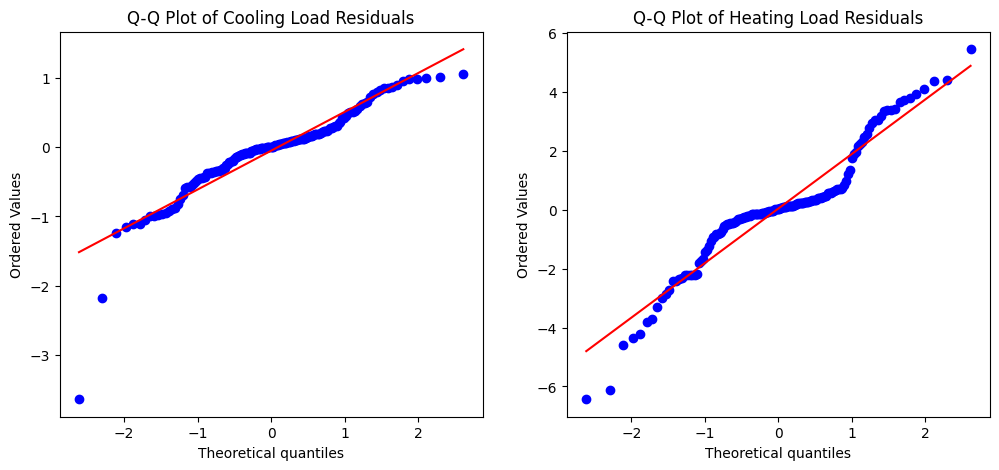

In [72]:
# Adding a Q-Q plot for Cooling and Heating Load
import scipy.stats as stats
fig, ax=plt.subplots(1, 2,figsize=(12,5))
stats.probplot(y_test.iloc[:, 0] - y_pred_rf[:, 0], dist="norm", plot=ax[0])
ax[0].set_title("Q-Q Plot of Cooling Load Residuals")
stats.probplot(y_test.iloc[:, 1] - y_pred_rf[:, 1], dist="norm", plot=ax[1])
ax[1].set_title("Q-Q Plot of Heating Load Residuals")
plt.show()

Text(0.5, 1.0, 'Residual Plot for Cooling Load')

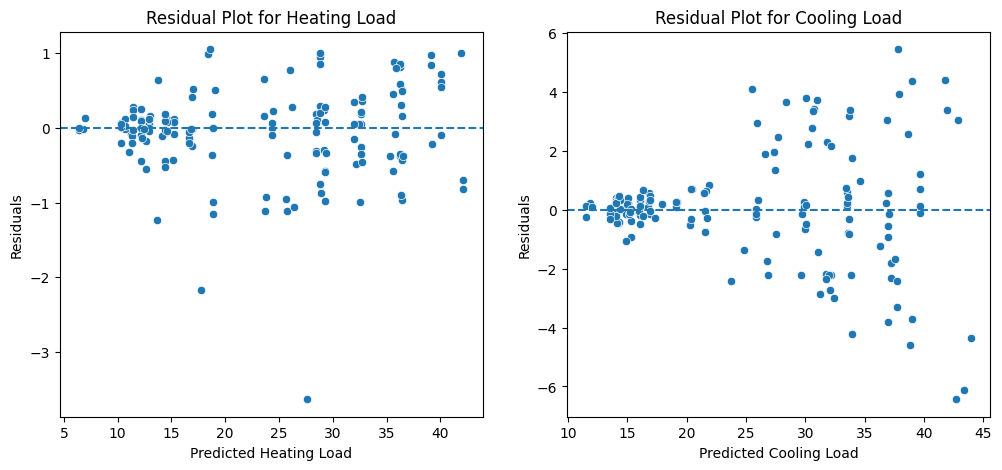

In [73]:
# Residual analysis for Heating and Cooling Load
fig, axes=plt.subplots(1, 2, figsize=(12,5))
residuals_cooling=y_test.iloc[:, 0]-y_pred_rf[:, 0]
sns.scatterplot(x=y_pred_rf[:, 0], y=residuals_cooling, ax=axes[0])
axes[0].axhline(0, linestyle="--")
axes[0].set_xlabel("Predicted Heating Load")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residual Plot for Heating Load")     
residuals_heating=y_test.iloc[:, 1]-y_pred_rf[:, 1]
sns.scatterplot(x=y_pred_rf[:, 1], y=residuals_heating, ax=axes[1])
axes[1].axhline(0, linestyle="--")
axes[1].set_xlabel("Predicted Cooling Load")
axes[1].set_ylabel("Residuals")
axes[1].set_title("Residual Plot for Cooling Load")

In [75]:
# For expalnability, we can check feature importance using SHAP values
!pip install shap
import shap

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.3.5 which is incompatible.
nba-api 1.6.0 requires numpy<2.0.0,>=1.22.2, but you have numpy 2.3.5 which is incompatible.


     ---------------------------------------- 0.0/60.9 kB ? eta -:--:--
     ---------------------------------------- 60.9/60.9 kB 1.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/549.3 kB ? eta -:--:--
   ---------- ----------------------------- 143.4/549.3 kB 2.8 MB/s eta 0:00:01
   -------------------------- ------------- 368.6/549.3 kB 4.6 MB/s eta 0:00:01
   ---------------------------------------- 549.3/549.3 kB 4.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   --------- ------------------------------ 0.7/2.8 MB 40.3 MB/s eta 0:00:01
   ----------------------------- ---------- 2.1/2.8 MB 25.9 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 24.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
   ------------- -------------------------- 4.4/12.8 MB 92.8 MB/s eta 0:00:01
   ---------------------------- ----------- 9.3/12.8 MB 99.5 MB/s eta 0:00:01
   --------

In [78]:
# Using SHAP for feature importance for heating and cooling load
explainer_0=shap.TreeExplainer(best_rf.named_steps['model'].estimators_[0])
explainer_1=shap.TreeExplainer(best_rf.named_steps['model'].estimators_[1])
X_transformed = best_rf.named_steps["preprocessor"].transform(X)
shap_values_0=explainer_0.shap_values(X_transformed)
shap_values_1=explainer_1.shap_values(X_transformed)
feature_names = best_rf.named_steps["preprocessor"].get_feature_names_out() 

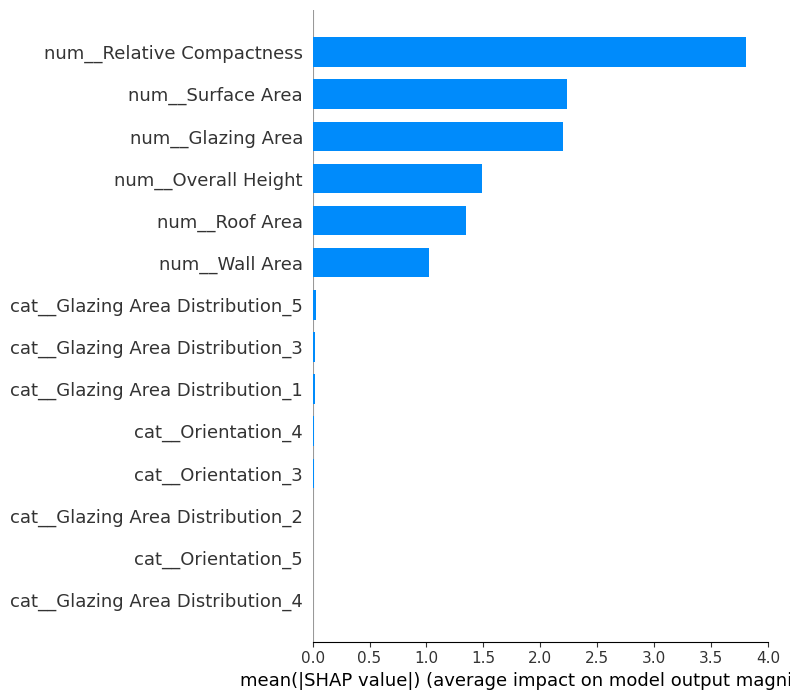

In [79]:
shap.summary_plot(
    shap_values_0,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

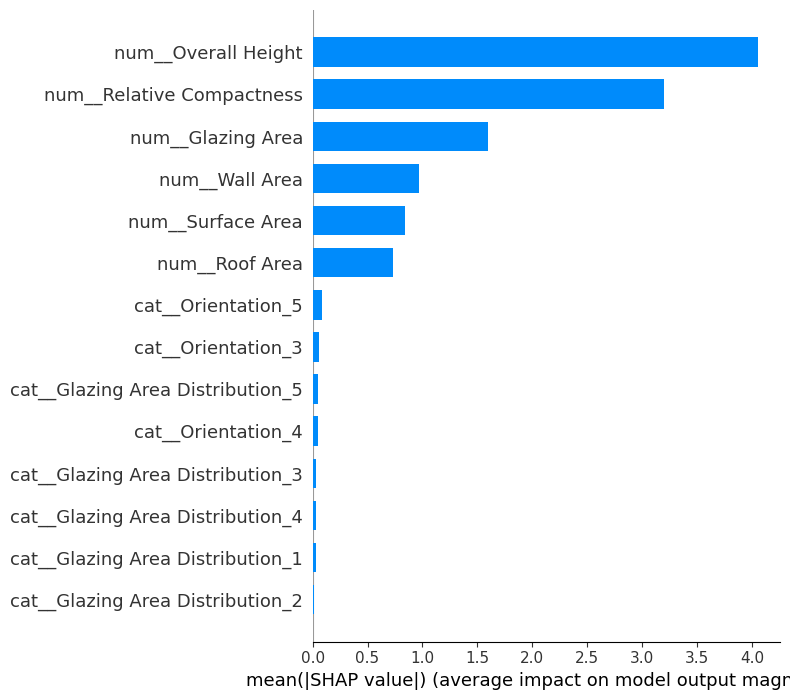

In [80]:
shap.summary_plot(
    shap_values_1,
    X_transformed,
    feature_names=feature_names,
    plot_type="bar"
)